# PROSIT 2 — Sprint 2: Custom Object Detection

**What this notebook does:**
1. Loads Roboflow-annotated Ghanaian road data
2. Builds a custom detection head on top of a CNN backbone
3. Implements classification, localisation, and objectness losses manually
4. Trains and evaluates using mAP@0.5
5. Shows domain shift comparison and failure analysis


## SECTION 0: Install & Imports

In [2]:
!pip install albumentations --quiet

import os, random, zipfile, json, math
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

Using device: cuda


## SECTION 1: Upload Roboflow Annotations

When Roboflow exports in YOLO format, you get:
- `images/train/`, `images/val/` — your frame images
- `labels/train/`, `labels/val/` — one `.txt` per image
- `data.yaml` — class names

Each label file has one row per object: `class_id cx cy w h` (all normalised 0-1)

In [4]:
import yaml

# Find data.yaml
yaml_path = list(Path('/kaggle/input/datasets/nicolenankabruce/annotated-data').rglob('data.yaml'))[0]
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg['names']
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Replace the 4 DIR lines and the train_imgs/val_imgs lines with this:
TRAIN_IMG_DIR = sorted(Path('/kaggle/input/datasets/nicolenankabruce/annotated-data').rglob('train/images'))[0]
TRAIN_LBL_DIR = sorted(Path('/kaggle/input/datasets/nicolenankabruce/annotated-data').rglob('train/labels'))[0]

all_imgs = sorted(TRAIN_IMG_DIR.glob('*.jpg')) + sorted(TRAIN_IMG_DIR.glob('*.png'))

# Split 80/20 manually
random.shuffle(all_imgs)
split = int(0.8 * len(all_imgs))
train_imgs = all_imgs[:split]
val_imgs   = all_imgs[split:]

# Point val labels to same folder as train labels (they're all in train/)
VAL_LBL_DIR   = TRAIN_LBL_DIR

print(f'Train images: {len(train_imgs)} | Val images: {len(val_imgs)}')

Classes (10): ['motorcycle', 'open drain', 'pedestrian', 'pothole', 'road sign', 'speed bump', 'street light', 'traffic light', 'vehicle', 'zebra crossing']
Train images: 80 | Val images: 20


In [5]:
def polygon_to_bbox(line):
    """Convert polygon label line to YOLO bbox format."""
    parts  = list(map(float, line.strip().split()))
    cls_id = int(parts[0])
    coords = parts[1:]
    
    xs = coords[0::2]
    ys = coords[1::2]
    
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2
    w  = x_max - x_min
    h  = y_max - y_min
    
    # Clamp everything to valid range
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    w  = max(0.0, min(1.0, w))
    h  = max(0.0, min(1.0, h))
    
    return f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"

In [6]:
import shutil

# Copy labels to working directory where we can edit them
WORKING_LBL_DIR = Path('/kaggle/working/converted_labels')
WORKING_LBL_DIR.mkdir(exist_ok=True)

# Copy all label files there
for lf in sorted(TRAIN_LBL_DIR.glob('*.txt')):
    shutil.copy(lf, WORKING_LBL_DIR / lf.name)

print(f'Copied {len(list(WORKING_LBL_DIR.glob("*.txt")))} label files to working dir')

# Now convert polygons to bboxes in the working copy
converted = 0
for lf in sorted(WORKING_LBL_DIR.glob('*.txt')):
    content = lf.read_text().strip()
    if not content:
        continue
    new_lines = []
    for line in content.splitlines():
        parts = line.strip().split()
        if len(parts) > 5:
            new_lines.append(polygon_to_bbox(line))
        elif len(parts) == 5:
            new_lines.append(line.strip())
    lf.write_text('\n'.join(new_lines))
    converted += 1

print(f'Converted {converted} files')
print('\nSample after conversion:')
print(list(WORKING_LBL_DIR.glob('*.txt'))[0].read_text()[:200])

# Update the label dir variable to point to converted labels
TRAIN_LBL_DIR = WORKING_LBL_DIR
VAL_LBL_DIR   = WORKING_LBL_DIR
print('\nTRAIN_LBL_DIR and VAL_LBL_DIR now point to converted labels')

Copied 100 label files to working dir
Converted 96 files

Sample after conversion:
8 0.387695 0.621094 0.044922 0.050781
5 0.424805 0.649414 0.216797 0.021484
4 0.548828 0.558594 0.011719 0.035156
0 0.504883 0.595703 0.005859 0.011719
1 0.069336 0.762695 0.138672 0.076172
2 0.208008

TRAIN_LBL_DIR and VAL_LBL_DIR now point to converted labels


/tmp/ipykernel_277/4156947812.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap('tab10', len(class_names))


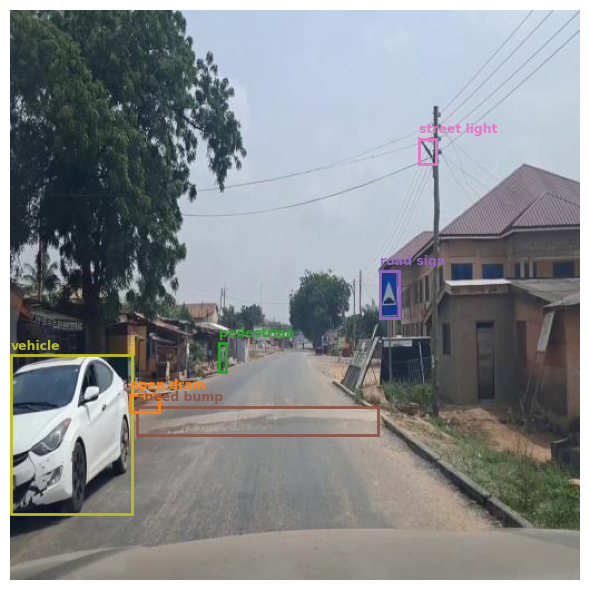

If you see coloured boxes on objects above, your annotations loaded correctly!


In [7]:
# Visualise one annotated frame to confirm labels loaded correctly
def load_yolo_labels(label_path):
    """Returns list of [class_id, cx, cy, w, h] in normalised coords."""
    boxes = []
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    boxes.append([float(x) for x in parts])
    return boxes

def show_annotated(img_path, lbl_path, class_names):
    img    = np.array(Image.open(img_path).convert('RGB'))
    boxes  = load_yolo_labels(lbl_path)
    H, W   = img.shape[:2]
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(img)
    colours = plt.cm.get_cmap('tab10', len(class_names))
    for cls_id, cx, cy, bw, bh in boxes:
        x1 = (cx - bw/2) * W
        y1 = (cy - bh/2) * H
        rect = patches.Rectangle((x1, y1), bw*W, bh*H,
                                   linewidth=2, edgecolor=colours(int(cls_id)), facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, class_names[int(cls_id)], color=colours(int(cls_id)),
                fontsize=9, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

sample_img = train_imgs[0]
sample_lbl = TRAIN_LBL_DIR / (sample_img.stem + '.txt')
show_annotated(sample_img, sample_lbl, CLASS_NAMES)
print('If you see coloured boxes on objects above, your annotations loaded correctly!')

In [8]:
# Check how many label files exist and how many have actual annotations
label_files = sorted(TRAIN_LBL_DIR.glob('*.txt'))
print(f'Total label files: {len(label_files)}')

empty    = 0
has_anno = 0
for lf in label_files:
    content = lf.read_text().strip()
    if content:
        has_anno += 1
    else:
        empty += 1

print(f'Files with annotations: {has_anno}')
print(f'Empty files:            {empty}')

# Also show the sample label file content
sample_lbl = TRAIN_LBL_DIR / (train_imgs[0].stem + '.txt')
print(f'\nLabel file for first image ({train_imgs[0].name}):')
print(sample_lbl.read_text() if sample_lbl.exists() else 'FILE NOT FOUND')

Total label files: 100
Files with annotations: 96
Empty files:            4

Label file for first image (frame_00177_jpg.rf.05f4043c537997d405541889a3bbf4d1.jpg):
2 0.371250 0.608887 0.012500 0.051852
6 0.730833 0.247341 0.030208 0.045370
4 0.665365 0.498148 0.032813 0.083333
5 0.433594 0.720370 0.423437 0.050000
8 0.106771 0.743981 0.213542 0.278704
1 0.234896 0.689352 0.051042 0.030556


## SECTION 2: Detection Dataset

We resize all images to 416x416 (standard for grid-based detection).
The grid divides the image into SxS cells. Each cell predicts B boxes.
This is a simplified YOLO-style approach built from scratch.

In [15]:
IMG_SIZE   = 416
GRID_SIZE  = 13   # 416 / 32 = 13 — each cell covers 32x32 pixels
NUM_BOXES  = 3    # anchor boxes per cell
NUM_ATTRS  = 5 + NUM_CLASSES  # [objectness, cx, cy, w, h, class_probs...]

# Anchor boxes (w, h) as fraction of image — tuned for road scene objects
ANCHORS = torch.tensor([
    [0.10, 0.10],   # small: potholes, cones
    [0.25, 0.30],   # medium: pedestrians, motorcycles
    [0.50, 0.40],   # large: cars, trotros
], dtype=torch.float32)

class DetectionDataset(Dataset):
    def __init__(self, img_paths, lbl_dir, augment=False):
        self.img_paths = img_paths
        self.lbl_dir   = Path(lbl_dir)
        self.augment   = augment
        self.transform = self._build_transform()

    def _build_transform(self):
        transforms = []
        if self.augment:
            transforms += [
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(0.3, 0.3, p=0.6),
                A.MotionBlur(blur_limit=(3,9), p=0.4),
                A.GaussNoise(var_limit=(10,40), p=0.4),
                A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.2),
            ]
        transforms += [
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2()
        ]
        return A.Compose(transforms,
                         bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'],
                                                   min_visibility=0.3))

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        lbl_path = self.lbl_dir / (img_path.stem + '.txt')

        image    = np.array(Image.open(img_path).convert('RGB'))
        raw_boxes = load_yolo_labels(lbl_path)

        if raw_boxes:
            bboxes, class_ids = [], []
            for b in raw_boxes:
                cx, cy, w, h = b[1], b[2], b[3], b[4]
                # Clamp to valid range before albumentations sees them
                x_min = max(0.0001, cx - w/2)
                y_min = max(0.0001, cy - h/2)
                x_max = min(0.9999, cx + w/2)
                y_max = min(0.9999, cy + h/2)
                # Skip degenerate boxes
                if x_max <= x_min or y_max <= y_min:
                    continue
                # Convert back to cx cy w h
                bboxes.append([
                    (x_min + x_max) / 2,
                    (y_min + y_max) / 2,
                    x_max - x_min,
                    y_max - y_min
                ])
                class_ids.append(int(b[0]))
        else:
            bboxes, class_ids = [], []
        out = self.transform(image=image, bboxes=bboxes, class_ids=class_ids)
        image  = out['image'].float()
        bboxes = out['bboxes']
        class_ids = out['class_ids']

        # Build target tensor: [GRID, GRID, NUM_BOXES, 5+NUM_CLASSES]
        target = torch.zeros(GRID_SIZE, GRID_SIZE, NUM_BOXES, NUM_ATTRS)
        for (cx, cy, bw, bh), cls_id in zip(bboxes, class_ids):
            cls_id = int(cls_id)
            # Which grid cell does the box centre fall in?
            gi = int(cx * GRID_SIZE)
            gj = int(cy * GRID_SIZE)
            gi = min(gi, GRID_SIZE-1)
            gj = min(gj, GRID_SIZE-1)

            # Which anchor best matches this box size?
            best_anchor = 0
            best_iou    = 0
            for a_idx, (aw, ah) in enumerate(ANCHORS):
                inter = min(bw, aw.item()) * min(bh, ah.item())
                union = bw*bh + aw.item()*ah.item() - inter
                iou   = inter / (union + 1e-6)
                if iou > best_iou:
                    best_iou, best_anchor = iou, a_idx

            # Fill target
            target[gj, gi, best_anchor, 0] = 1.0           # objectness
            target[gj, gi, best_anchor, 1] = cx * GRID_SIZE - gi   # local cx offset
            target[gj, gi, best_anchor, 2] = cy * GRID_SIZE - gj   # local cy offset
            target[gj, gi, best_anchor, 3] = math.log(bw / ANCHORS[best_anchor,0].item() + 1e-6)
            target[gj, gi, best_anchor, 4] = math.log(bh / ANCHORS[best_anchor,1].item() + 1e-6)
            target[gj, gi, best_anchor, 5 + cls_id] = 1.0  # one-hot class

        return image, target

train_dataset = DetectionDataset(train_imgs, TRAIN_LBL_DIR, augment=True)
val_dataset   = DetectionDataset(val_imgs,   VAL_LBL_DIR,   augment=False)
train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')

Train: 80 | Val: 20


/tmp/ipykernel_277/2891567627.py:27: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10,40), p=0.4),
/tmp/ipykernel_277/2891567627.py:28: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.2),


## SECTION 3: Detection Architecture

We use a MobileNetV2 backbone (efficient, pre-trained on ImageNet) with a
**custom detection head** built from scratch.

The detection head outputs a grid of predictions:
for each of the 13x13 cells, it predicts 3 boxes, each with:
- **objectness score**: is there an object here?
- **cx, cy**: where exactly in the cell is the box centre?
- **w, h**: box dimensions (relative to anchor size)
- **class probabilities**: which of the 8 classes is it?

In [16]:
class DetectionHead(nn.Module):
    """Custom detection head — built from scratch as required."""
    def __init__(self, in_channels, num_boxes, num_classes):
        super().__init__()
        mid = 256
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, mid, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid), nn.LeakyReLU(0.1)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(mid, mid, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid), nn.LeakyReLU(0.1)
        )
        # Final layer: outputs (5 + num_classes) values per anchor per cell
        self.pred  = nn.Conv2d(mid, num_boxes * (5 + num_classes), 1)
        self.num_boxes   = num_boxes
        self.num_classes = num_classes

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pred(x)  # [B, num_boxes*(5+C), G, G]
        B, _, G, _ = x.shape
        # Reshape to [B, G, G, num_boxes, 5+C]
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(B, G, G, self.num_boxes, 5 + self.num_classes)
        return x


class RoadDetector(nn.Module):
    """
    Full detection model:
    MobileNetV2 backbone (pre-trained) + custom detection head (from scratch)
    """
    def __init__(self, num_classes, num_boxes=3):
        super().__init__()
        backbone = torchvision.models.mobilenet_v2(pretrained=True)
        # Use features up to the last spatial layer
        self.backbone = backbone.features  # outputs [B, 1280, 13, 13] for 416x416 input
        self.head = DetectionHead(1280, num_boxes, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


model = RoadDetector(NUM_CLASSES).to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
head_only = sum(p.numel() for p in model.head.parameters())
print(f'Total params: {total:,} | Detection head params: {head_only:,}')

Total params: 5,775,405 | Detection head params: 3,551,533


## SECTION 4: Detection Loss (Implemented Manually)

This is the core requirement of Sprint 2. The loss has **three components**:

1. **Objectness Loss** — Binary cross-entropy on whether a cell contains an object.
   Penalises both missed detections and false alarms.

2. **Localisation Loss** — MSE on box coordinates (cx, cy, w, h).
   Only computed for cells that actually contain an object.

3. **Classification Loss** — Binary cross-entropy on class probabilities.
   Only computed for cells that actually contain an object.

The total loss is a weighted sum of all three.

In [17]:
class DetectionLoss(nn.Module):
    """
    Manual YOLO-style detection loss.
    Implements objectness + localisation + classification losses from scratch.
    """
    def __init__(self, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        # lambda_coord: upweights localisation loss (boxes matter a lot)
        # lambda_noobj: downweights background cells (most cells have no object)
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.bce = nn.BCEWithLogitsLoss(reduction='sum')
        self.mse = nn.MSELoss(reduction='sum')

    def forward(self, predictions, targets):
        """
        predictions: [B, G, G, NUM_BOXES, 5+C]  (raw logits from model)
        targets:     [B, G, G, NUM_BOXES, 5+C]  (ground truth)
        """
        # obj_mask: cells that DO contain an object in ground truth
        obj_mask  = targets[..., 0] == 1   # [B, G, G, NUM_BOXES]
        noobj_mask = ~obj_mask

        # ── 1. OBJECTNESS LOSS ─────────────────────────────────────────────
        # For cells WITH objects: penalise if model says no object
        # For cells WITHOUT objects: penalise if model says there is an object
        obj_loss   = self.bce(
            predictions[..., 0][obj_mask],
            targets[..., 0][obj_mask]
        )
        noobj_loss = self.bce(
            predictions[..., 0][noobj_mask],
            targets[..., 0][noobj_mask]
        )
        objectness_loss = obj_loss + self.lambda_noobj * noobj_loss

        # ── 2. LOCALISATION LOSS ───────────────────────────────────────────
        # Only computed for cells that contain an object
        # Predicts: [cx_offset, cy_offset, log(w/anchor_w), log(h/anchor_h)]
        if obj_mask.sum() > 0:
            pred_coords = predictions[..., 1:5][obj_mask]  # [N, 4]
            true_coords = targets[..., 1:5][obj_mask]      # [N, 4]

            # Centre coordinates: sigmoid to keep in [0,1] range of cell
            pred_xy = torch.sigmoid(pred_coords[:, :2])
            true_xy = true_coords[:, :2]

            # Width/height: direct regression (log-space)
            pred_wh = pred_coords[:, 2:]
            true_wh = true_coords[:, 2:]

            coord_loss = self.mse(pred_xy, true_xy) + self.mse(pred_wh, true_wh)
            localisation_loss = self.lambda_coord * coord_loss

            # ── 3. CLASSIFICATION LOSS ─────────────────────────────────────
            # Which class is in this cell? (one-hot target)
            pred_cls = predictions[..., 5:][obj_mask]   # [N, C]
            true_cls = targets[..., 5:][obj_mask]       # [N, C]
            classification_loss = self.bce(pred_cls, true_cls)
        else:
            localisation_loss  = torch.tensor(0.0, device=predictions.device)
            classification_loss = torch.tensor(0.0, device=predictions.device)

        total_loss = objectness_loss + localisation_loss + classification_loss

        return total_loss, {
            'objectness':     objectness_loss.item(),
            'localisation':   localisation_loss.item(),
            'classification': classification_loss.item(),
            'total':          total_loss.item()
        }


criterion = DetectionLoss(lambda_coord=5.0, lambda_noobj=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
print('Loss function and optimiser ready.')

Loss function and optimiser ready.


## SECTION 5: Non-Maximum Suppression (implemented manually)

After the model predicts hundreds of boxes, NMS removes duplicates.
It keeps only the highest-confidence box when multiple boxes overlap the same object.

In [18]:
def decode_predictions(raw_preds, anchors, conf_threshold=0.3):
    """
    Convert raw model output to (x1, y1, x2, y2, confidence, class_id) boxes.
    raw_preds: [B, G, G, NUM_BOXES, 5+C]
    """
    B, G, _, NB, NC = raw_preds.shape
    boxes_per_image = []

    for b in range(B):
        boxes = []
        for gj in range(G):
            for gi in range(G):
                for a in range(NB):
                    pred = raw_preds[b, gj, gi, a]
                    obj  = torch.sigmoid(pred[0]).item()
                    if obj < conf_threshold:
                        continue
                    cx = (gi + torch.sigmoid(pred[1]).item()) / G
                    cy = (gj + torch.sigmoid(pred[2]).item()) / G
                    bw = anchors[a, 0].item() * math.exp(pred[3].item())
                    bh = anchors[a, 1].item() * math.exp(pred[4].item())
                    cls_probs  = torch.softmax(pred[5:], dim=0)
                    cls_id     = cls_probs.argmax().item()
                    confidence = obj * cls_probs[cls_id].item()
                    x1 = max(0, cx - bw/2)
                    y1 = max(0, cy - bh/2)
                    x2 = min(1, cx + bw/2)
                    y2 = min(1, cy + bh/2)
                    boxes.append([x1, y1, x2, y2, confidence, cls_id])
        boxes_per_image.append(boxes)
    return boxes_per_image


def box_iou(box1, box2):
    """IoU between two boxes [x1,y1,x2,y2]."""
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    a1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def nms(boxes, iou_threshold=0.45):
    """
    Manual Non-Maximum Suppression.
    boxes: list of [x1, y1, x2, y2, confidence, class_id]
    Returns filtered list keeping only the best box per object.
    """
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)  # sort by confidence
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        # Remove any box that heavily overlaps with 'best' AND is same class
        boxes = [b for b in boxes
                 if b[5] != best[5] or box_iou(best[:4], b[:4]) < iou_threshold]
    return kept

print('NMS implemented manually.')

NMS implemented manually.


## SECTION 6: mAP@0.5 Evaluation Metric

In [19]:
def compute_map(model, loader, anchors, iou_threshold=0.5, conf_threshold=0.3):
    """
    Compute mAP@0.5 across all classes.
    mAP = mean Average Precision = average area under precision-recall curve per class.
    """
    model.eval()
    all_preds = defaultdict(list)   # class_id -> [(confidence, is_tp)]
    all_gt    = defaultdict(int)    # class_id -> total ground truth count

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(DEVICE)
            raw  = model(imgs)
            preds_batch = decode_predictions(raw.cpu(), anchors, conf_threshold)

            for b_idx, pred_boxes in enumerate(preds_batch):
                pred_boxes = nms(pred_boxes)
                target     = targets[b_idx]  # [G, G, NB, 5+C]

                # Collect ground truth boxes from target tensor
                gt_boxes = []
                obj_cells = (target[..., 0] == 1).nonzero(as_tuple=False)
                for cell in obj_cells:
                    gj, gi, a = cell
                    t = target[gj, gi, a]
                    cls_id = t[5:].argmax().item()
                    all_gt[cls_id] += 1
                    cx = (gi.item() + t[1].item()) / GRID_SIZE
                    cy = (gj.item() + t[2].item()) / GRID_SIZE
                    bw = anchors[a, 0].item() * math.exp(t[3].item())
                    bh = anchors[a, 1].item() * math.exp(t[4].item())
                    gt_boxes.append([cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2, cls_id])

                matched_gt = set()
                for pred in sorted(pred_boxes, key=lambda x: -x[4]):
                    cls_id = int(pred[5])
                    is_tp  = False
                    for gt_idx, gt in enumerate(gt_boxes):
                        if gt[4] == cls_id and gt_idx not in matched_gt:
                            if box_iou(pred[:4], gt[:4]) >= iou_threshold:
                                is_tp = True
                                matched_gt.add(gt_idx)
                                break
                    all_preds[cls_id].append((pred[4], float(is_tp)))

    # Compute AP per class
    aps = {}
    for cls_id in range(NUM_CLASSES):
        if all_gt[cls_id] == 0:
            continue
        preds_cls = sorted(all_preds.get(cls_id, []), key=lambda x: -x[0])
        tp = np.cumsum([p[1] for p in preds_cls])
        fp = np.cumsum([1-p[1] for p in preds_cls])
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (all_gt[cls_id] + 1e-6)
        # Compute area under PR curve
        mrec = np.concatenate([[0], recall, [1]])
        mpre = np.concatenate([[0], precision, [0]])
        for i in range(len(mpre)-2, -1, -1):
            mpre[i] = max(mpre[i], mpre[i+1])
        ap = np.sum((mrec[1:]-mrec[:-1]) * mpre[1:])
        aps[CLASS_NAMES[cls_id]] = ap

    mAP = np.mean(list(aps.values())) if aps else 0.0
    return mAP, aps

print('mAP evaluation function ready.')

mAP evaluation function ready.


## SECTION 7: Training Loop

In [20]:
NUM_EPOCHS   = 30
anchors_cpu  = ANCHORS  # keep on CPU for decode
history      = defaultdict(list)
best_map     = 0

print('Training detection model...')
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_losses = defaultdict(float)

    for imgs, targets in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False):
        imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss, loss_dict = criterion(preds, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        for k, v in loss_dict.items():
            epoch_losses[k] += v

    scheduler.step()
    for k in epoch_losses:
        epoch_losses[k] /= len(train_loader)
        history[k].append(epoch_losses[k])

    if epoch % 5 == 0 or epoch == NUM_EPOCHS:
        val_map, per_class_ap = compute_map(model, val_loader, anchors_cpu)
        history['val_mAP'].append(val_map)
        print(f'Epoch {epoch:02d} | Loss: {epoch_losses["total"]:.3f} '
              f'(obj:{epoch_losses["objectness"]:.2f} '
              f'loc:{epoch_losses["localisation"]:.2f} '
              f'cls:{epoch_losses["classification"]:.2f}) | '
              f'mAP@0.5: {val_map:.4f}')
        if val_map > best_map:
            best_map = val_map
            torch.save(model.state_dict(), 'detector_best.pth')
    else:
        print(f'Epoch {epoch:02d} | Loss: {epoch_losses["total"]:.3f}')

print(f'\nBest mAP@0.5: {best_map:.4f}')

Training detection model...


Epoch 01 | Loss: 2473.159


Epoch 02 | Loss: 2031.649


Epoch 03 | Loss: 1829.638


Epoch 04 | Loss: 1650.688


...

Epoch 26 | Loss: 616.952


Epoch 27 | Loss: 609.834


Epoch 28 | Loss: 602.553


Epoch 29 | Loss: 599.222


Epoch 30 | Loss: 602.670 (obj:377.24 loc:114.92 cls:110.51) | mAP@0.5: 0.0001

Best mAP@0.5: 0.0096


## SECTION 8: Visualise Detections

/tmp/ipykernel_277/3195171484.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap('tab10', len(class_names))


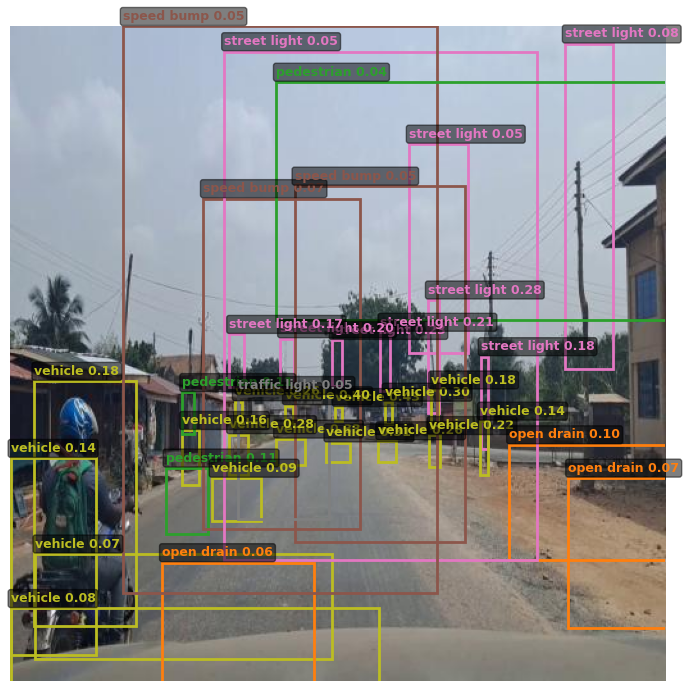

frame_00196-copy_jpg.rf.1893d4de9dda9ff811145931aeb27ac3.jpg: 36 detections after NMS


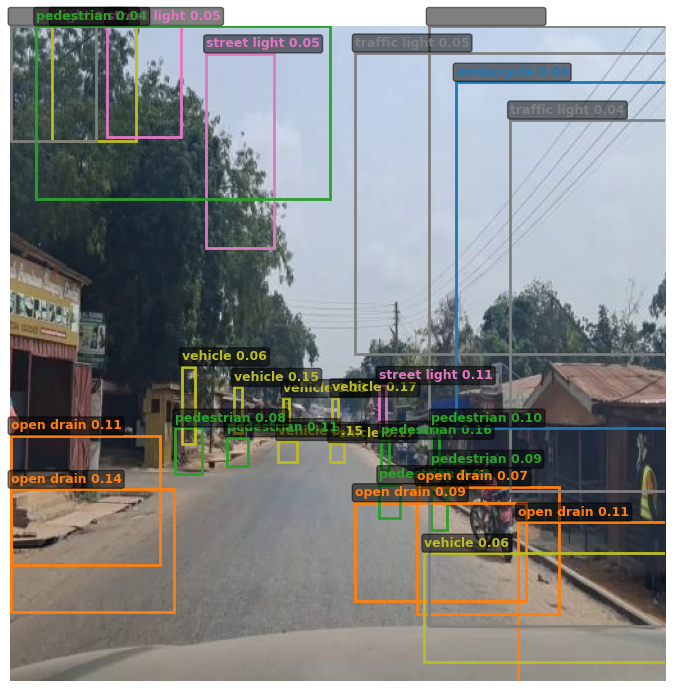

frame_00160_jpg.rf.476a19ca61b42a699e3a48fb96b68a8d.jpg: 28 detections after NMS


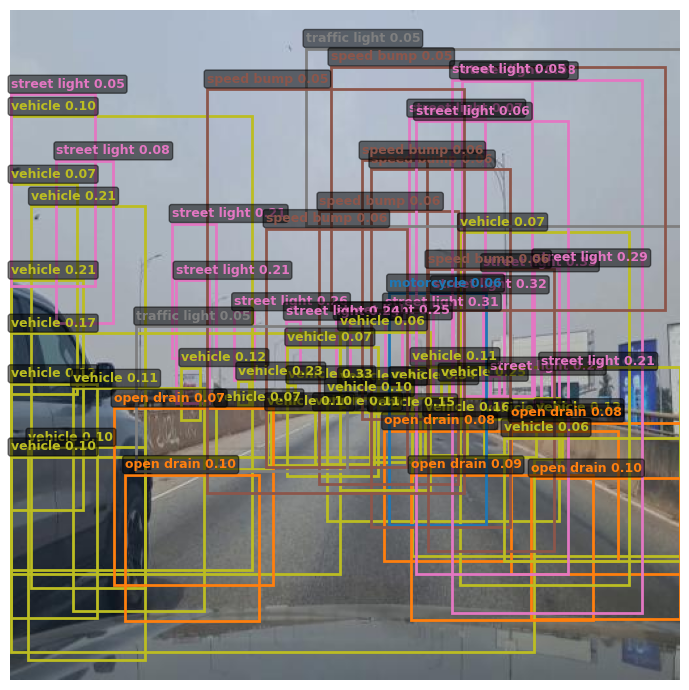

frame_00054-copy_jpg.rf.58916d6b50c66fef09119c7b2f7cd8c8.jpg: 61 detections after NMS


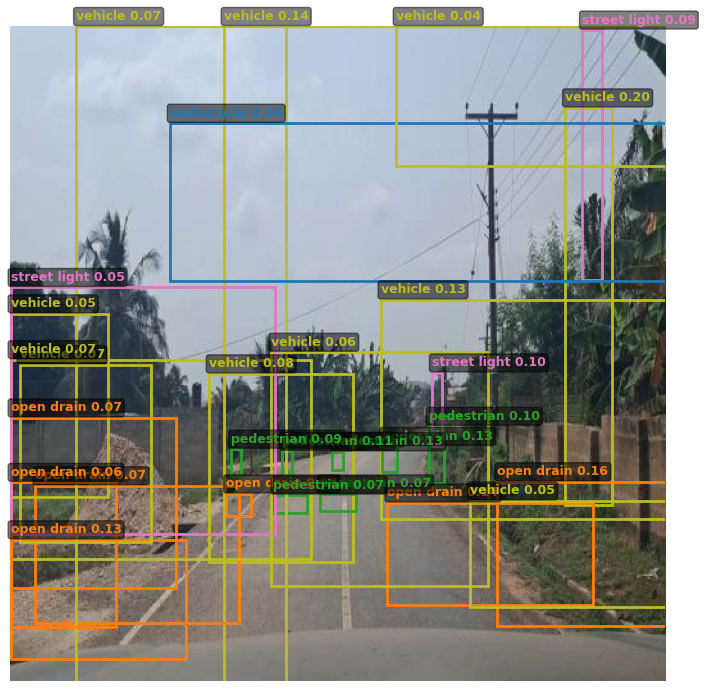

video1_frame000810_png.rf.f8b03caf23d2f4ad91bc2412b78528e3.jpg: 29 detections after NMS


In [21]:
model.load_state_dict(torch.load('detector_best.pth', map_location=DEVICE))
model.eval()

def visualise_detections(img_path, model, anchors, class_names, conf_thresh=0.3):
    img_np  = np.array(Image.open(img_path).convert('RGB'))
    H, W    = img_np.shape[:2]
    transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2()
    ])
    inp = transform(image=img_np)['image'].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        raw = model(inp)
    boxes = nms(decode_predictions(raw.cpu(), anchors, conf_thresh)[0])

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(img_np)
    colours = plt.cm.get_cmap('tab10', len(class_names))
    for (x1, y1, x2, y2, conf, cls_id) in boxes:
        rect = patches.Rectangle((x1*W, y1*H), (x2-x1)*W, (y2-y1)*H,
                                   linewidth=2, edgecolor=colours(int(cls_id)), facecolor='none')
        ax.add_patch(rect)
        label = f"{class_names[int(cls_id)]} {conf:.2f}"
        ax.text(x1*W, y1*H-5, label, color=colours(int(cls_id)),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return len(boxes)

# Show detections on 4 validation images
for img_path in val_imgs[:4]:
    n = visualise_detections(img_path, model, anchors_cpu, CLASS_NAMES)
    print(f'{img_path.name}: {n} detections after NMS')

## SECTION 9: Per-Class AP Results & Failure Analysis


Final mAP@0.5: 0.0096
open drain           AP=0.0940  ██
vehicle              AP=0.0020  
motorcycle           AP=0.0000  
pedestrian           AP=0.0000  
pothole              AP=0.0000  
road sign            AP=0.0000  
speed bump           AP=0.0000  
street light         AP=0.0000  
traffic light        AP=0.0000  
zebra crossing       AP=0.0000  


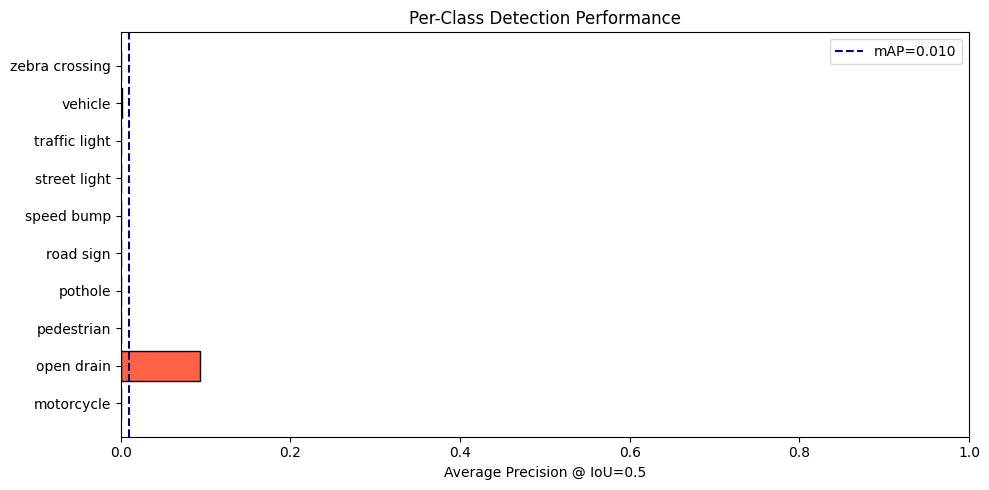


Classes in RED (AP < 0.3) are your hardest failure cases — explain these in your report.


In [22]:
final_map, per_class = compute_map(model, val_loader, anchors_cpu)

print('\n' + '='*50)
print(f'Final mAP@0.5: {final_map:.4f}')
print('='*50)
for cls_name, ap in sorted(per_class.items(), key=lambda x: -x[1]):
    bar = '█' * int(ap * 30)
    print(f'{cls_name:20s} AP={ap:.4f}  {bar}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(per_class.keys())
vals  = list(per_class.values())
colours = ['tomato' if v < 0.3 else 'gold' if v < 0.5 else 'mediumseagreen' for v in vals]
ax.barh(names, vals, color=colours, edgecolor='black')
ax.set_xlim(0, 1)
ax.axvline(final_map, color='navy', linestyle='--', label=f'mAP={final_map:.3f}')
ax.set_xlabel('Average Precision @ IoU=0.5')
ax.set_title('Per-Class Detection Performance')
ax.legend()
plt.tight_layout()
plt.savefig('detection_results.png', dpi=150)
plt.show()

print('\nClasses in RED (AP < 0.3) are your hardest failure cases — explain these in your report.')

## SECTION 10: Download Outputs
Save everything needed for your Sprint 2 submission.

In [24]:
import os
import shutil
import json
import torch
from IPython.display import FileLink

# Use the specific Kaggle working path
output_dir = '/kaggle/working/sprint2_outputs'
os.makedirs(output_dir, exist_ok=True)

# Copy files (Ensure 'detection_results.png' exists in your current folder)
shutil.copy('detection_results.png', f'{output_dir}/')
torch.save(model.state_dict(), f'{output_dir}/detector_best.pth')

summary = {
    'mAP_at_0.5': round(final_map, 4),
    'per_class_AP': {k: round(v, 4) for k, v in per_class.items()},
    'num_train_images': len(train_imgs),
    'num_val_images': len(val_imgs),
    'classes': CLASS_NAMES
}

with open(f'{output_dir}/results.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Create the zip in the main working directory
shutil.make_archive('sprint2_outputs', 'zip', output_dir)

# Generate the clickable download link
print('Click the link below to download your results:')
display(FileLink('sprint2_outputs.zip'))


Click the link below to download your results:


/kaggle/working/sprint2_outputs.zip

## SPRINT 3: VLM-Assisted Failure Mining

In [25]:
!pip install transformers -q

from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image
import torch

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
blip_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base").to(DEVICE)
blip_model.eval()
print("BLIP VQA loaded!")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP VQA loaded!


In [26]:
FAILURE_QUERIES = {
    'shadow_confusion': 'Are there shadows on the road that look like damage?',
    'dust_haze':        'Is there dust or haze reducing visibility?',
    'dense_crowd':      'Are there many people or vehicles crowded together?',
    'low_contrast':     'Is the road hard to distinguish from surroundings?',
    'motion_blur':      'Is the image blurry or affected by motion?',
    'informal_objects': 'Are there unusual informal objects on the road?',
    'partial_occlusion':'Are any people or vehicles partially hidden?'
}

YES_WORDS = ['yes', 'there are', 'there is', 'visible', 'can be seen']

def ask_blip(image_path, question):
    image  = Image.open(image_path).convert('RGB')
    inputs = blip_processor(image, question, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=20)
    return blip_processor.decode(out[0], skip_special_tokens=True).lower()

def score_frame(img_path):
    scores = {}
    for failure_type, question in FAILURE_QUERIES.items():
        answer = ask_blip(img_path, question)
        scores[failure_type] = 1 if any(w in answer for w in YES_WORDS) else 0
    scores['total_flags'] = sum(v for k,v in scores.items() if k != 'total_flags')
    return scores

# Test on one frame first
print("Testing on one frame...")
test_score = score_frame(val_imgs[0])
for k, v in test_score.items():
    print(f"  {'⚠️' if v else '✓ '} {k}")

Testing on one frame...
  ✓  shadow_confusion
  ✓  dust_haze
  ✓  dense_crowd
  ⚠️ low_contrast
  ✓  motion_blur
  ✓  informal_objects
  ⚠️ partial_occlusion
  ⚠️ total_flags


In [27]:
from collections import defaultdict

print(f"Mining failures across {len(val_imgs)} frames...")
frame_scores = {}
for img_path in tqdm(val_imgs):
    frame_scores[str(img_path)] = score_frame(img_path)

# Summary
print("\nFailure mode frequency:")
for failure_type in FAILURE_QUERIES:
    count = sum(1 for s in frame_scores.values() if s.get(failure_type, 0) == 1)
    pct   = 100 * count / len(val_imgs)
    bar   = '█' * int(pct / 5)
    print(f"  {failure_type:25s}: {count:2d} frames ({pct:.0f}%) {bar}")

Mining failures across 20 frames...


100%|██████████| 20/20 [00:13<00:00,  1.51it/s]


Failure mode frequency:
  shadow_confusion         :  1 frames (5%) █
  dust_haze                :  0 frames (0%) 
  dense_crowd              :  0 frames (0%) 
  low_contrast             : 18 frames (90%) ██████████████████
  motion_blur              :  0 frames (0%) 
  informal_objects         :  0 frames (0%) 
  partial_occlusion        : 13 frames (65%) █████████████


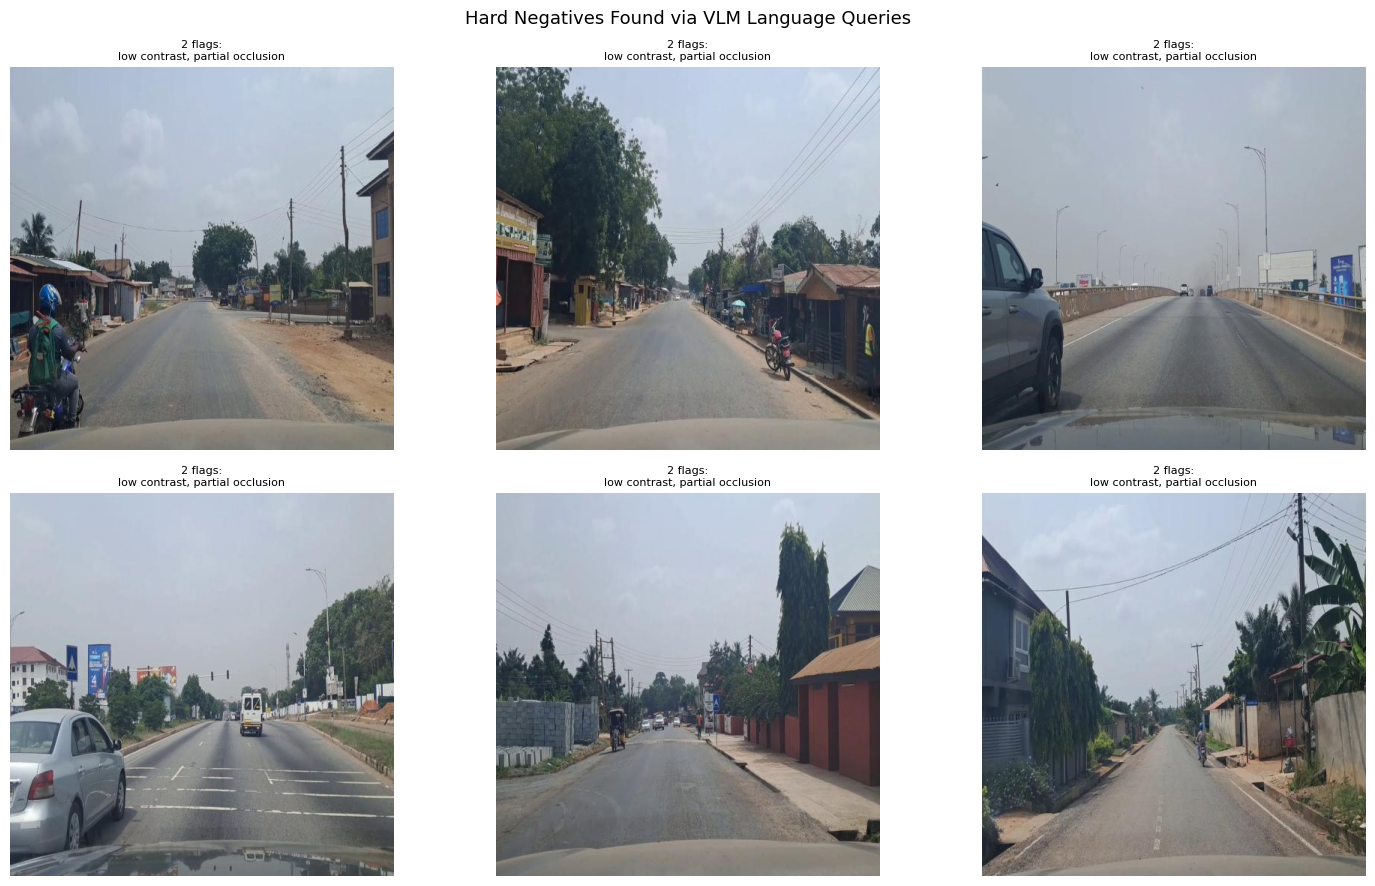

In [28]:
# Sort by most failure flags
sorted_frames = sorted(frame_scores.items(), key=lambda x: -x[1]['total_flags'])
hard_negatives = [Path(p) for p, _ in sorted_frames[:6]]
hard_scores    = [s for _, s in sorted_frames[:6]]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path, score in zip(axes.flat, hard_negatives, hard_scores):
    img   = Image.open(img_path).convert('RGB')
    flags = [k.replace('_',' ') for k,v in score.items()
             if v == 1 and k != 'total_flags']
    ax.imshow(img)
    ax.set_title(f"{score['total_flags']} flags:\n" + ', '.join(flags[:2]), fontsize=8)
    ax.axis('off')

plt.suptitle('Hard Negatives Found via VLM Language Queries', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/hard_negatives.png', dpi=150)
plt.show()

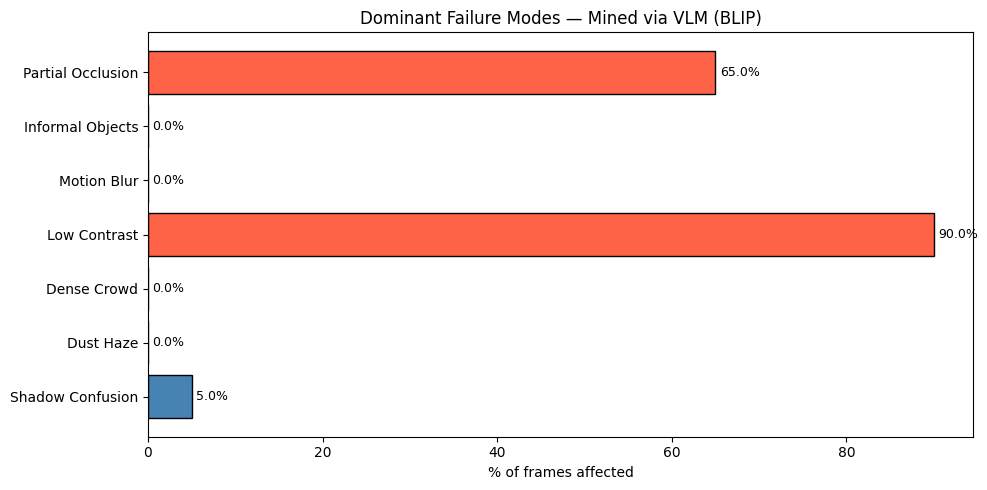

{
  "total_frames_analysed": 20,
  "hard_negatives_found": 6,
  "failure_mode_percentages": {
    "shadow_confusion": 5.0,
    "dust_haze": 0.0,
    "dense_crowd": 0.0,
    "low_contrast": 90.0,
    "motion_blur": 0.0,
    "informal_objects": 0.0,
    "partial_occlusion": 65.0
  },
  "dominant_failure": "low_contrast",
  "mAP_before_hard_negative_retraining": 0.0096,
  "vlm_model_used": "Salesforce/blip-vqa-base"
}


In [29]:
import json

# Bar chart
failure_counts = {k: sum(1 for s in frame_scores.values() if s.get(k,0)==1)
                  for k in FAILURE_QUERIES}
failure_pcts   = {k: round(100*v/len(val_imgs),1) for k,v in failure_counts.items()}

fig, ax = plt.subplots(figsize=(10, 5))
labels  = [k.replace('_',' ').title() for k in failure_counts]
values  = list(failure_pcts.values())
colours = ['tomato' if v > 40 else 'gold' if v > 20 else 'steelblue' for v in values]
ax.barh(labels, values, color=colours, edgecolor='black')
ax.set_xlabel('% of frames affected')
ax.set_title('Dominant Failure Modes — Mined via VLM (BLIP)')
for i, v in enumerate(values):
    ax.text(v+0.5, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/failure_modes.png', dpi=150)
plt.show()

# Save report data
report = {
    'total_frames_analysed': len(val_imgs),
    'hard_negatives_found':  len(hard_negatives),
    'failure_mode_percentages': failure_pcts,
    'dominant_failure': max(failure_pcts, key=failure_pcts.get),
    'mAP_before_hard_negative_retraining': round(final_map, 4),
    'vlm_model_used': 'Salesforce/blip-vqa-base'
}
with open('/kaggle/working/sprint3_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))

In [30]:
import shutil

os.makedirs('/kaggle/working/sprint3_outputs', exist_ok=True)

# Copy all sprint 3 outputs
for fname in ['hard_negatives.png', 'failure_modes.png', 'sprint3_report.json']:
    src = Path(f'/kaggle/working/{fname}')
    if src.exists():
        shutil.copy(src, f'/kaggle/working/sprint3_outputs/{fname}')

shutil.make_archive('/kaggle/working/sprint3_outputs', 'zip', 
                    '/kaggle/working/sprint3_outputs')
print('Done! Go to /kaggle/working/ in the right sidebar and download sprint3_outputs.zip')

Done! Go to /kaggle/working/ in the right sidebar and download sprint3_outputs.zip
